In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys 
sys.path.append('../src')

from cnn import * 
from datas import * 
from train import *

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
full_bed = '../data/bed_files/SOX2_clusters_sorted.bed'
full_bed = pd.read_csv(full_bed, sep='\t')
full_bed

,#chrom,start,end,name,score,strand,thickStart,thickEnd,itemRGB,blockCount,blockSizes,blockStart,deepTools_group
0,chr17,28970879,29007995,NM_134115.3,0.0,-,28970879,29007995,0,1,37116,28970877,cluster_1
1,chr6,122707564,122714633,NM_028016.3,0.0,+,122707564,122714633,0,1,7069,122707563,cluster_1
2,chr15,103191545,103239852,NM_001076789.2,0.0,-,103191545,103239852,0,1,48307,103191544,cluster_1
3,chr6,39397820,39420369,NM_018810.2,0.0,-,39397820,39420369,0,1,22549,39397817,cluster_1
4,chr6,144993834,145076157,NM_007532.5,0.0,-,144993834,145076157,0,1,82323,144993833,cluster_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20989,chrY,8832248,8835169,NM_001017394.2,0.0,-,8832248,8835169,0,1,2921,8832240,cluster_4
20990,chrY,7636215,7636973,NM_001101623.1,0.0,-,7636215,7636973,0,1,758,7636208,cluster_4
20991,chrY,3771672,3783271,NM_001270512.1,0.0,+,3771672,3783271,0,1,11599,3771669,cluster_4
20992,chrY,3367142,3378783,NM_001270515.1,0.0,-,3367142,3378783,0,1,11641,3367139,cluster_4


In [5]:
timepoint = '2H'
bigwig_path = '../data/bws_for_predictor/SPT16_4D_2HdTAG_Sox2_S46_1_120_sorted.bw'

# timepoint = 'DMSO'
# bigwig_path = '../data/bws_for_predictor/SPT16_4D_DMSO_Sox2_S40_1_120_sorted.bw'

fasta_path = '../data/GRCm38.primary_assembly.genome.fa'
bed_path = '../data/bed_files/SOX2_clusters_sorted.bed'
# bed_path = '../data/bed_files/GFP_TTseq_max_sorted_top_quintile.bed'

signal_bins = None
batch_size = 256
epochs = 1000
lr = 1e-3
weight_decay=1e-4
device = 'mps'
patience = 10
sidelines = 0
target_smoothing = False
subset_cluster = 'cluster_1'
rc_augment = True

In [6]:
window_left = 1000
window_right = 1000
model_dir = 'models'

In [7]:
dataset = SequenceBigWigDataset(
    fasta_path=str(fasta_path),
    bigwig_path=str(bigwig_path),
    bed_path=str(bed_path),
    signal_bins=signal_bins,
    window_left=window_left,
    window_right=window_right,
    subset_dict={'deepTools_group': subset_cluster}
)

In [8]:
min_profile = window_left + window_right
min_profile

2000

### Sanity check window profile

In [9]:
len(dataset)

517

In [10]:
from torch.utils.data import DataLoader
import numpy as np

loader = DataLoader(dataset, batch_size=256, num_workers=1, shuffle=False)

tot_counts = []
for _, y_batch in loader:
    tot_counts.append(y_batch.numpy())

tot_counts = np.vstack(tot_counts)
tot_counts.shape

(517, 2000)

'2H'

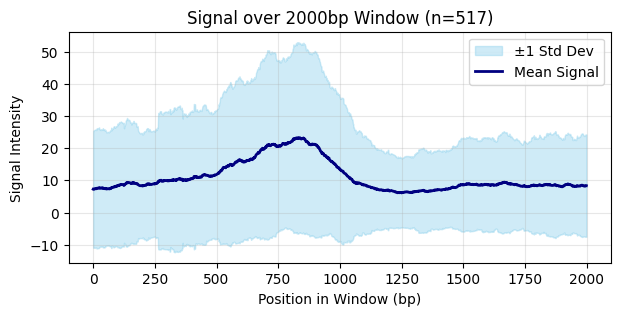

In [11]:
mean_line = np.mean(tot_counts, axis=0)
std_line = np.std(tot_counts, axis=0)
x = np.arange(len(mean_line))

plt.figure(figsize=(7, 3))

plt.fill_between(x, mean_line - std_line, mean_line + std_line, 
                 color='skyblue', alpha=0.4, label='±1 Std Dev')

plt.plot(x, mean_line, color='navy', lw=2, label='Mean Signal')

plt.title(f"Signal over {len(mean_line)}bp Window (n={tot_counts.shape[0]})")
plt.xlabel("Position in Window (bp)")
plt.ylabel("Signal Intensity")
plt.legend()
plt.grid(True, alpha=0.3)

timepoint

### Training

In [12]:
# real training
config = TrainConfig(
    lr=lr,
    weight_decay=weight_decay,
    epochs=epochs,
    device=device,
    patience=patience,
    loss_type='bpnet',
    min_profile=min_profile,
    sidelines=sidelines,
    target_smoothing=target_smoothing,
    rc_augment=rc_augment
)

model = train_cnn_regressor(
    dataset=dataset,
    batch_size=batch_size,
    config=config,
)

Receptive field: 535 bp (Sequence length: 2000 bp)


Epoch 1/1000 - train: 1421332.5000 | val: 802810.1176 (counts: 460489.6471, profile: 342320.4706)
Epoch 2/1000 - train: 505195.3281 | val: 471616.7843 (counts: 171082.3725, profile: 300534.4314)
Epoch 3/1000 - train: 443969.4219 | val: 403838.9804 (counts: 143438.7451, profile: 260400.2353)
Epoch 4/1000 - train: 318769.9531 | val: 250195.4902 (counts: 13906.5221, profile: 236288.9608)
Epoch 5/1000 - train: 217401.6875 | val: 226067.2549 (counts: 3207.4473, profile: 222859.8039)
Epoch 6/1000 - train: 202362.3438 | val: 232847.5098 (counts: 17905.7059, profile: 214941.8039)
Epoch 7/1000 - train: 208586.6875 | val: 233749.5686 (counts: 23629.3480, profile: 210120.2157)
Epoch 8/1000 - train: 205237.5703 | val: 225137.3333 (counts: 17934.4804, profile: 207202.8627)
Epoch 9/1000 - train: 196919.5391 | val: 212650.0392 (counts: 7228.6238, profile: 205421.4118)
Epoch 10/1000 - train: 185478.8516 | val: 204803.4510 (counts: 648.7019, profile: 204154.7451)
Epoch 11/1000 - train: 182787.6406 | va

In [13]:
import time
from pathlib import Path

date = time.strftime("%m%d")
model_name = f'seq_{timepoint}_{subset_cluster}_{date}'
output_model_path = Path(f'../{model_dir}/{model_name}.pt')

model.save_model(output_model_path)
model_name

'seq_2H_cluster_1_0519'

In [14]:
import os 
os.makedirs(f'../{model_dir}/loaders', exist_ok=True)

import torch
torch.save(model.val_loader, f'../{model_dir}/loaders/{model_name}_val.pt')
torch.save(model.test_loader, f'../{model_dir}/loaders/{model_name}_test.pt')
torch.save(model.train_loader, f'../{model_dir}/loaders/{model_name}_train.pt')

### Evaluate

In [15]:
%matplotlib inline
import os
import torch
from torch.utils.data import DataLoader

In [16]:
# model_name = 'seq_DMSO_cluster_1_0519'
# model_name = 'seq_DMSO_cluster_2_0519'
# model_name = 'seq_2H_cluster_2_0519'
model_name = 'seq_2H_cluster_1_0519'

results_dir = f'../results/{model_name}'
os.makedirs(results_dir, exist_ok=True)

In [17]:
model = BPNetModel.load_model(f'../models/{model_name}.pt')
model.test_loader = torch.load(f'../models/loaders/{model_name}_test.pt', weights_only=False)
model.train_loader = torch.load(f'../models/loaders/{model_name}_train.pt', weights_only=False)
model.val_loader = torch.load(f'../models/loaders/{model_name}_val.pt', weights_only=False)

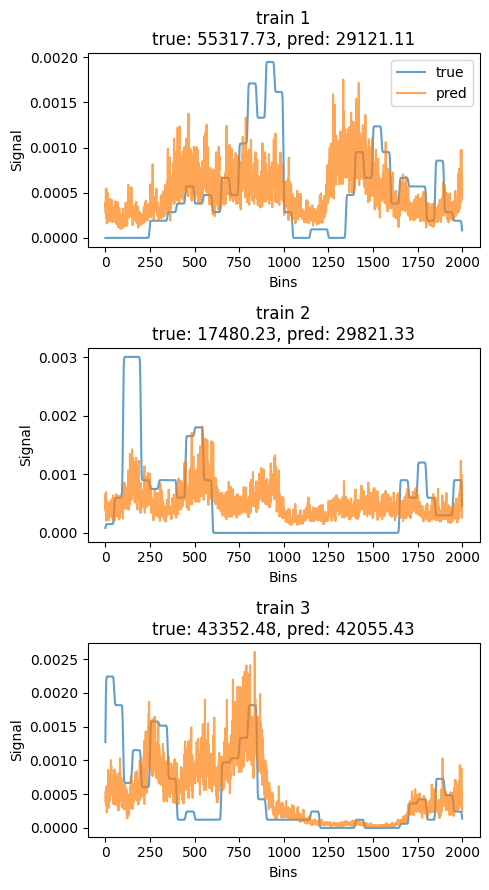

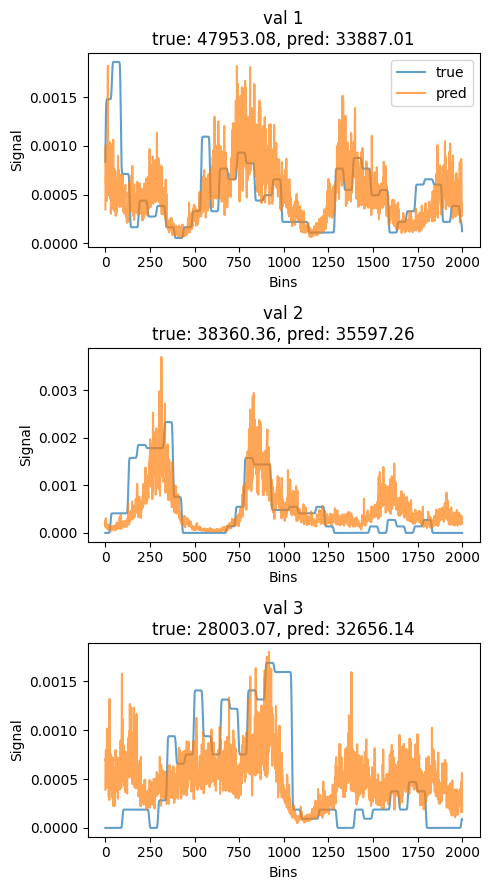

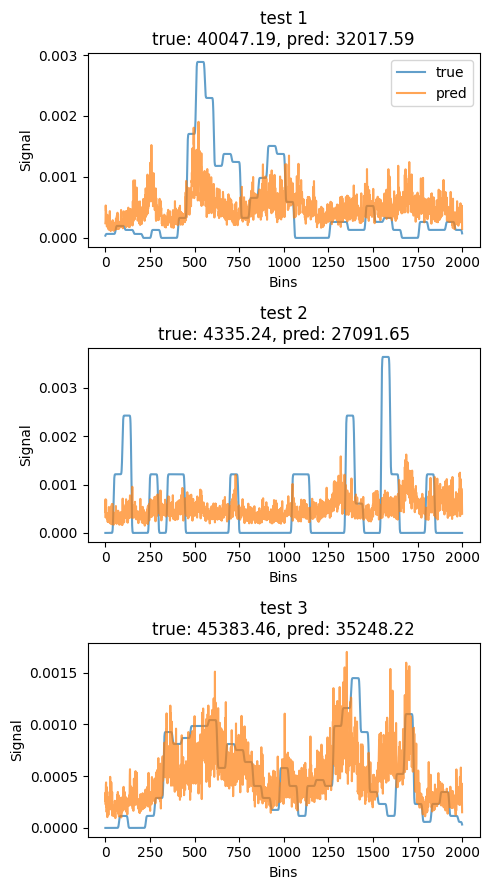

In [18]:
visualize_split_predictions(
    model,
    device='cpu',
    n_examples_per_split=3,
    smooth_true=True
)

Evaluating Train split...
Evaluating Validation split...
Evaluating Test split...
Evaluating Uniform split...
Evaluating Permuted split...
Evaluating Gaussian split...


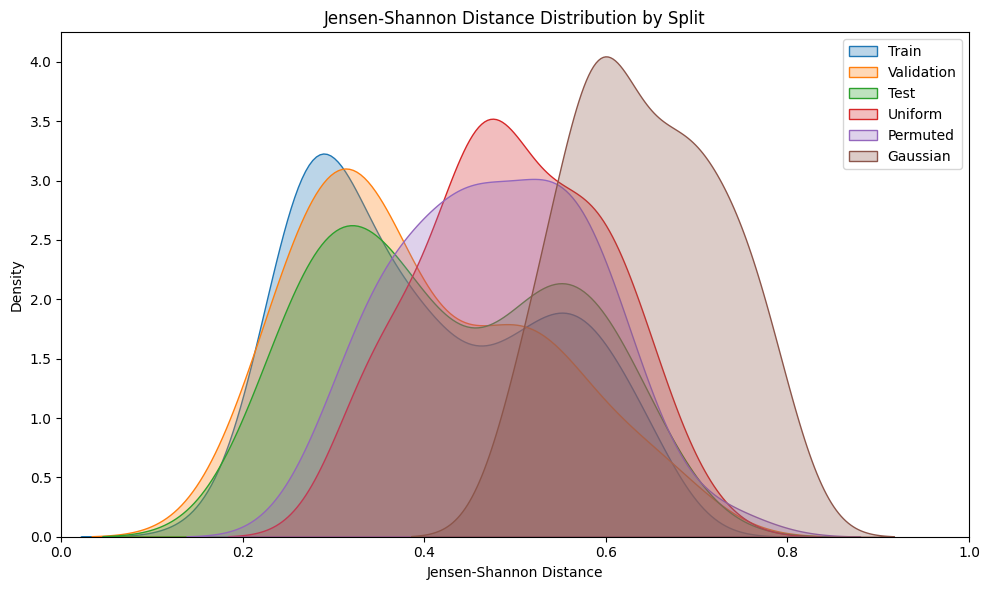

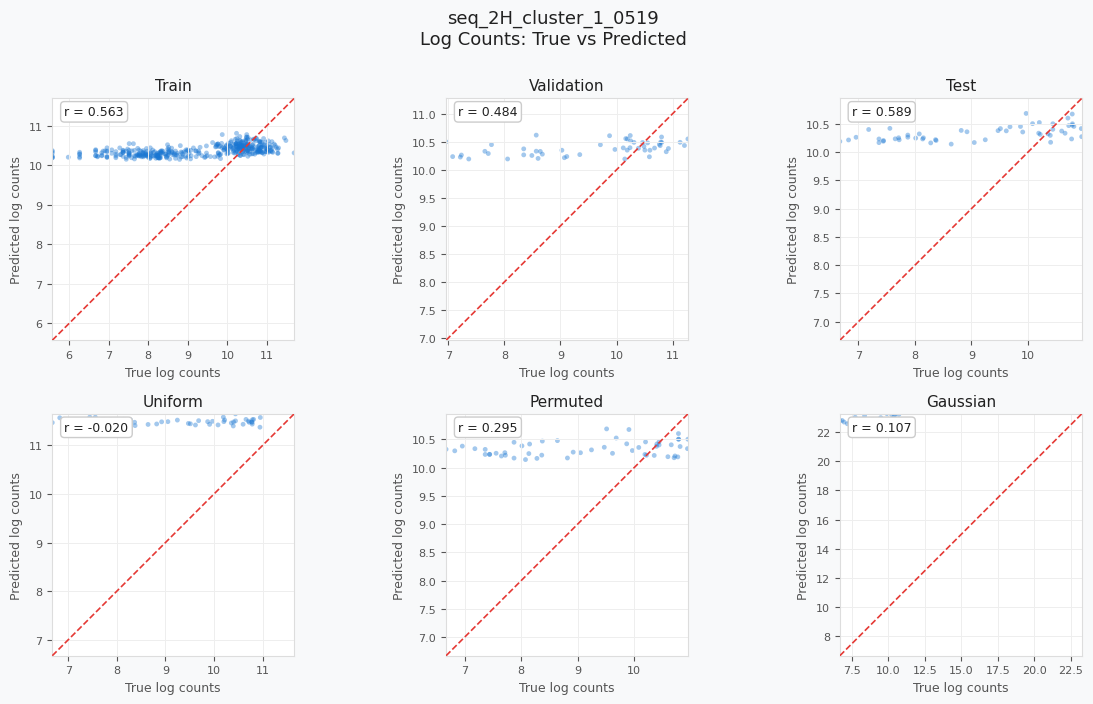

In [19]:
from evaluate import evaluate_baselines, plot_counts_correlation, evaluate_baselines_sig

df_corr, loader_metrics = evaluate_baselines(model, results_dir=results_dir)
# df_stats = evaluate_baselines_sig(loader_metrics, results_dir=results_dir)

plot_counts_correlation(loader_metrics, model_name=model_name, results_dir=results_dir)

### Track motifs

In [20]:
import os
import torch

os.environ['NUMBA_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['KMP_WARNINGS'] = '0'

if torch.backends.mps.is_available():
    torch.mps.empty_cache()

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="captum")
    

In [21]:
loader = DataLoader(dataset, batch_size=256, num_workers=1, shuffle=False)
len(loader.dataset)

517

Indexing intervals by total signal...
Running Knockout Test (n=100)...
Running Implant Test (n=100)...

ISM DIAGNOSTIC SUMMARY
Knockout (n=100):
  Mean Motif Delta: -13.65
  Mean Ctrl Delta:   +1.44
  Wilcoxon p-val:    1.78e-02

Implant (n=100):
  Mean Motif Delta: +41.92
  Mean Rand Delta:  +23.14
  Wilcoxon p-val:    2.15e-04



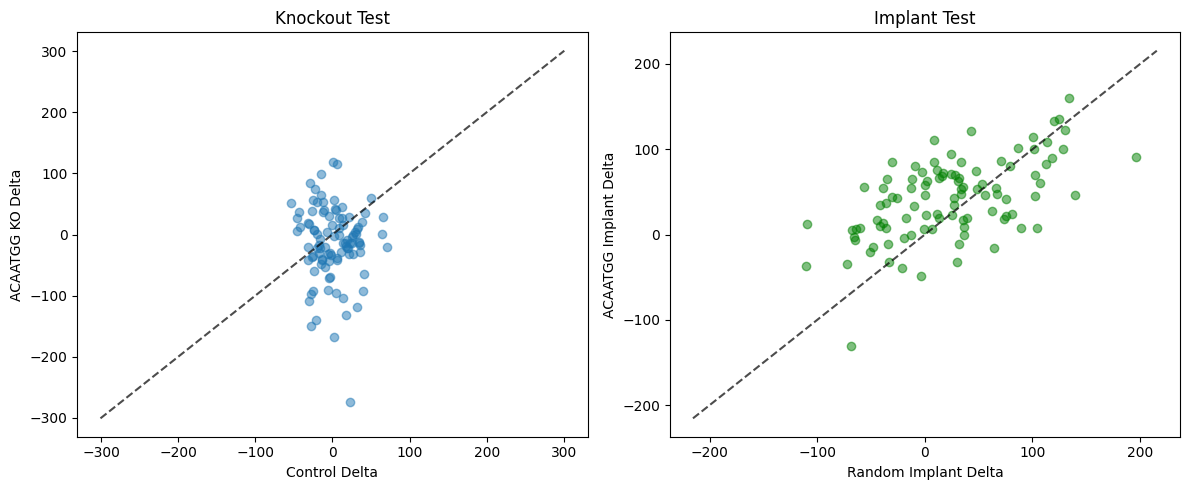

Indexing intervals by total signal...
Running Knockout Test (n=100)...
Running Implant Test (n=100)...

ISM DIAGNOSTIC SUMMARY
Knockout (n=100):
  Mean Motif Delta: -0.17
  Mean Ctrl Delta:   -2.32
  Wilcoxon p-val:    6.27e-01

Implant (n=100):
  Mean Motif Delta: +29.01
  Mean Rand Delta:  +23.14
  Wilcoxon p-val:    7.53e-02



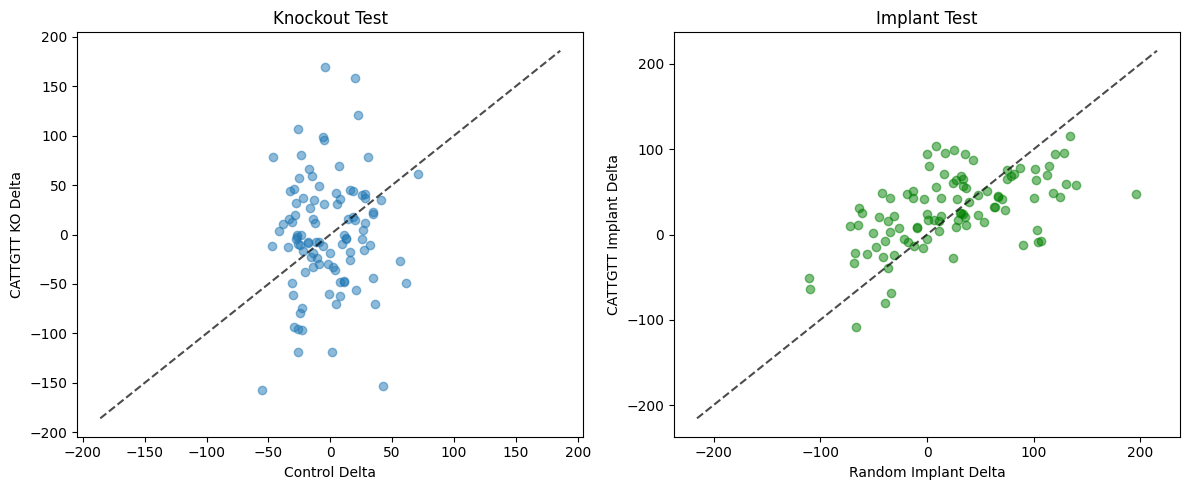

In [22]:
from check import run_ism_diagnostic, plot_ism_diagnostic
%matplotlib inline

motif = "ACAATGG"
ko_df, imp_df = run_ism_diagnostic(model, dataset, motif_seq=motif, device='mps', n_high=100, n_low=100)
fig = plot_ism_diagnostic(ko_df, imp_df, motif_name=motif)

motif = "CATTGTT" 
ko_df, imp_df = run_ism_diagnostic(model, dataset, motif_seq=motif, device='mps', n_high=100, n_low=100)
fig = plot_ism_diagnostic(ko_df, imp_df, motif_name=motif)

Scanning sequences and extracting attributions for SOX2...
  Processed 100 sequences
  Processed 200 sequences
  skipped 169 (jsd distance >= 0.45)
Scanning sequences and extracting attributions for PATZ1...
  Processed 100 sequences
  Processed 200 sequences
  skipped 169 (jsd distance >= 0.45)


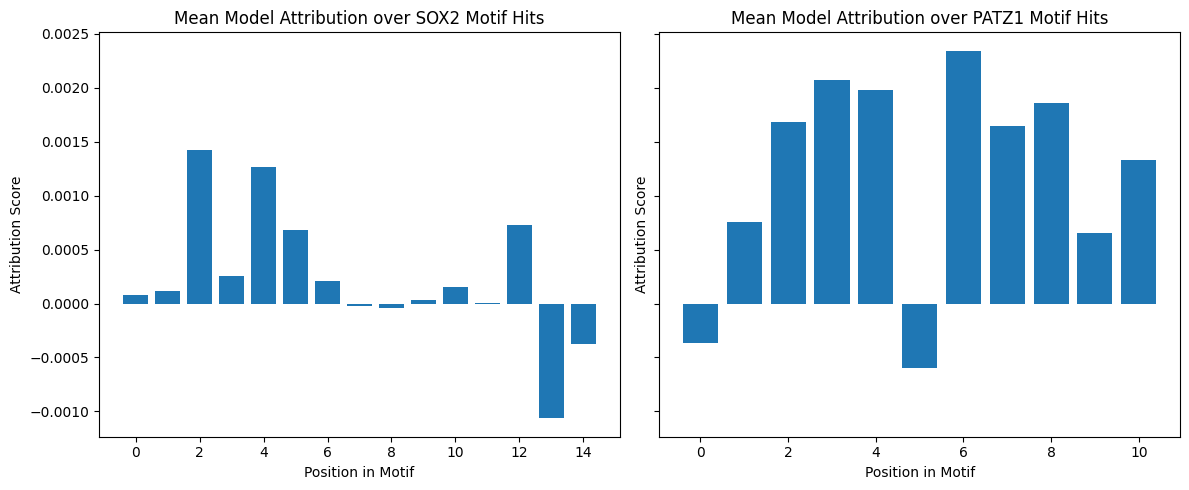

In [23]:
from motif_match import match_motifs_to_attributions
%matplotlib inline 

meme_path = '../data/JASPAR2024_CORE_vertebrates.meme'
motifs = ["SOX2", "PATZ1"]
device = 'mps'

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, motif in zip(axes, motifs):
    attrs, scores = match_motifs_to_attributions(
        model, 
        loader=loader, 
        meme_path=meme_path, 
        motif_name=motif, 
        device=device, 
        head="profile", 
        n_seqs=5000, 
        min_counts=model.min_profile,
        jsd_thresh=0.45
    )
    
    mean_attr = attrs.sum(axis=1).mean(axis=0)
    
    ax.bar(range(len(mean_attr)), mean_attr)
    ax.set_title(f"Mean Model Attribution over {motif} Motif Hits")
    ax.set_xlabel("Position in Motif")
    ax.set_ylabel("Attribution Score")

plt.tight_layout()
plt.show()


In [ ]:
from motif import discover_motifs

pos, neg = discover_motifs(
    model, 
    loader=loader, 
    device='mps', 
    sliding_window_size=7,
    min_counts=model.min_profile, 
    jsd_thresh=0.45,
    save_path=f'{results_dir}/modisco_profile.h5', 
)

Generating attributions on mps...
  kept 274 sequences for attribution
  skipped 74 (below min_counts=2000)
  skipped 0 (low complexity, max_base_fraction>0.55)
  skipped 169 (jsd distance >= 0.45)
Executing MoDISco-lite on 274 sequences (window=7, flank=4, FDR=0.25, leiden=100)...
Using 1288 positive seqlets
Extracted 2937 negative seqlets


In [ ]:
print(f'modisco report -i {results_dir}/modisco_profile.h5 -o {results_dir}/report/  -m ../data/JASPAR2024_CORE_vertebrates.meme')

modisco report -i ../results/seq_2H_cluster_2_0519/modisco_profile.h5 -o ../results/seq_2H_cluster_2_0519/report/  -m ../data/JASPAR2024_CORE_vertebrates.meme


In [ ]:
from motif import read_report 

html_path = f'{results_dir}/report/motifs.html'
meme_path = '../data/JASPAR2024_CORE_vertebrates.meme'

df = read_report(html_path, meme_path)
df

,num_seqlets,match0,match0_name,qval0,match1,match1_name,qval1,match2,match2_name,qval2
pattern,,,,,,,,,,
pos_patterns.pattern_0,98,MA1111.2,NR2F2,0.441199,MA1539.1,NR2F6,0.441199,MA2338.1,Ppara,0.441199
pos_patterns.pattern_1,88,MA0052.5,MEF2A,1.000000,MA2124.1,Hmga1,1.000000,MA1518.3,Lhx1,1.000000
pos_patterns.pattern_2,80,MA1125.2,ZNF384,0.009204,MA0757.2,ONECUT3,1.000000,MA0041.3,FOXD3,1.000000
pos_patterns.pattern_3,72,MA1125.2,ZNF384,0.720394,MA2323.1,Pgr,0.720394,MA1124.1,ZNF24,1.000000
pos_patterns.pattern_4,71,MA1981.2,ZNF530,1.000000,MA1991.2,Hnf1A,1.000000,MA1548.2,PLAGL2,1.000000
pos_patterns.pattern_5,69,MA1125.2,ZNF384,0.049092,MA0497.2,MEF2C,0.831233,MA0901.3,HOXB13,0.831233
pos_patterns.pattern_6,66,MA0502.3,NFYB,0.451229,MA0163.1,PLAG1,1.000000,MA2122.1,Ebf4,1.000000
pos_patterns.pattern_7,63,MA0729.1,RARA,0.651130,MA2120.1,ZNF184,0.651130,MA0857.1,Rarb,0.959728
pos_patterns.pattern_8,62,MA0729.1,RARA,1.000000,MA1983.2,ZNF582,1.000000,MA0878.3,CDX1,1.000000


In [ ]:
df.to_csv(f'{results_dir}/matches.csv')